## Train test split

In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd

In [2]:
df_churn = pd.DataFrame(pd.read_csv('updated_churn_dataset.csv'))

X = df_churn.drop(columns=["churn"])
y = df_churn["churn"]


In [7]:
# Remove irrelevant columns for model training
irrelevant_columns = [
    "user_id",
    "churn",
    "registration_date",
    "observation_start_date",
    "observation_end_date",
    "first_live_bet_date",
    "last_live_bet_date",
    "live_bets_count_outcome_window"
]

X = df_churn.drop(columns=irrelevant_columns)
y = df_churn["churn"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

## Logistic Regression

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pickle

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, class_weight="balanced"))
    # ("model", LogisticRegression(random_state=42))
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

with open("lr_churn_trained_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

## Random Forrest

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

## XGBoost

In [11]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

## Evaluation

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate(name, y_true, pred, prob):
    print(f"\n{name}")
    print("--------------------------------------")
    print("Accuracy :", accuracy_score(y_true, pred))
    print("Precision:", precision_score(y_true, pred))
    print("Recall   :", recall_score(y_true, pred))
    print("F1       :", f1_score(y_true, pred))
    print("ROC AUC  :", roc_auc_score(y_true, prob))

In [13]:
evaluate("Logistic Regression", y_test, lr_pred, lr_prob)
evaluate("Random Forest", y_test, rf_pred, rf_prob)
evaluate("XGBoost", y_test, xgb_pred, xgb_prob)


Logistic Regression
--------------------------------------
Accuracy : 0.7165
Precision: 0.3595933926302414
Recall   : 0.8179190751445087
F1       : 0.499558693733451
ROC AUC  : 0.8399361156348946

Random Forest
--------------------------------------
Accuracy : 0.84
Precision: 0.5738636363636364
Recall   : 0.29190751445086704
F1       : 0.38697318007662834
ROC AUC  : 0.8263764145074823

XGBoost
--------------------------------------
Accuracy : 0.8375
Precision: 0.559322033898305
Recall   : 0.2861271676300578
F1       : 0.37858508604206503
ROC AUC  : 0.8258312306477202


## Confusion Matrix

Logistic regression confusion matrix
Random forrest confusion matrix
XGBoost confusion matrix


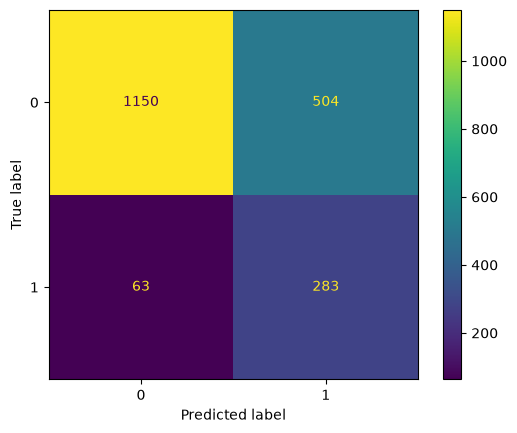

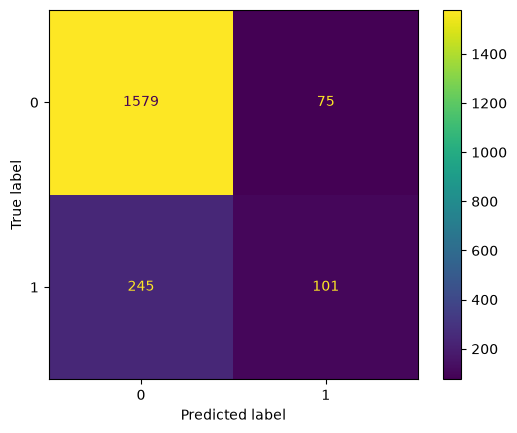

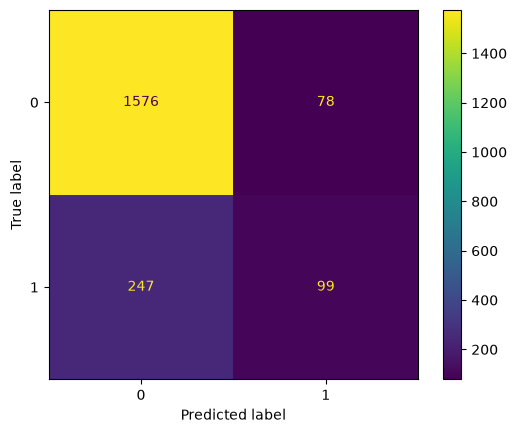

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Logistic regression confusion matrix")
ConfusionMatrixDisplay.from_estimator(lr_model, X_test, y_test)

print("Random forrest confusion matrix")
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)

print("XGBoost confusion matrix")
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test)

plt.show()

## Classification Report

In [15]:
from sklearn.metrics import classification_report

print("Logistic regression classification report \n")
print(classification_report(y_test, lr_pred))

print("Random forrest classification report \n")
print(classification_report(y_test, rf_pred))

print("XGBoost classification report \n")
print(classification_report(y_test, xgb_pred))

Logistic regression classification report 

              precision    recall  f1-score   support

           0       0.95      0.70      0.80      1654
           1       0.36      0.82      0.50       346

    accuracy                           0.72      2000
   macro avg       0.65      0.76      0.65      2000
weighted avg       0.85      0.72      0.75      2000

Random forrest classification report 

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1654
           1       0.57      0.29      0.39       346

    accuracy                           0.84      2000
   macro avg       0.72      0.62      0.65      2000
weighted avg       0.82      0.84      0.82      2000

XGBoost classification report 

              precision    recall  f1-score   support

           0       0.86      0.95      0.91      1654
           1       0.56      0.29      0.38       346

    accuracy                           0.84      2000
   macro avg 